In [6]:
pip install numpy matplotlib pillow tifffile imagecodecs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 79.6 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [9]:
import os
from glob import glob

# Define your base path based on the folder structure
base_path = "/kaggle/input/inria-aerial-image-labeling-dataset/AerialImageDataset"

train_images_path = os.path.join(base_path, "train/images")
train_gt_path = os.path.join(base_path, "train/gt")
test_images_path = os.path.join(base_path, "test/images")

# Get list of files
train_img_files = sorted(glob(os.path.join(train_images_path, "*.tif")))
train_gt_files = sorted(glob(os.path.join(train_gt_path, "*.tif")))
test_img_files = sorted(glob(os.path.join(test_images_path, "*.tif")))

print(f"Number of Train Images: {len(train_img_files)}")
print(f"Number of Train Masks:  {len(train_gt_files)}")
print(f"Number of Test Images:  {len(test_img_files)}")

# Sanity Check: Ensure every image has a corresponding mask
if len(train_img_files) == len(train_gt_files):
    print("✅ Counts match between Train Images and GT.")
else:
    print("❌ Mismatch in file counts!")

Number of Train Images: 180
Number of Train Masks:  180
Number of Test Images:  180
✅ Counts match between Train Images and GT.


In [10]:
from PIL import Image
import numpy as np

# Load the first image and mask to check properties
# We convert to numpy array immediately to check shapes/values
sample_img = np.array(Image.open(train_img_files[0]))
sample_mask = np.array(Image.open(train_gt_files[0]))

print(f"Image Shape: {sample_img.shape}")  # Expected: (Height, Width, 3)
print(f"Mask Shape:  {sample_mask.shape}") # Expected: (Height, Width)
print(f"Image Dtype: {sample_img.dtype}")
print(f"Mask Dtype:  {sample_mask.dtype}")

# Check value ranges
print(f"Image Min/Max: {sample_img.min()}, {sample_img.max()}")
print(f"Mask Min/Max:  {sample_mask.min()}, {sample_mask.max()}")

# Unique values in mask
unique_values = np.unique(sample_mask)
print(f"Unique values in mask: {unique_values}") 
# Note: Inria usually uses 255 for buildings and 0 for background.

Image Shape: (5000, 5000, 3)
Mask Shape:  (5000, 5000)
Image Dtype: uint8
Mask Dtype:  uint8
Image Min/Max: 0, 255
Mask Min/Max:  0, 255
Unique values in mask: [  0 255]


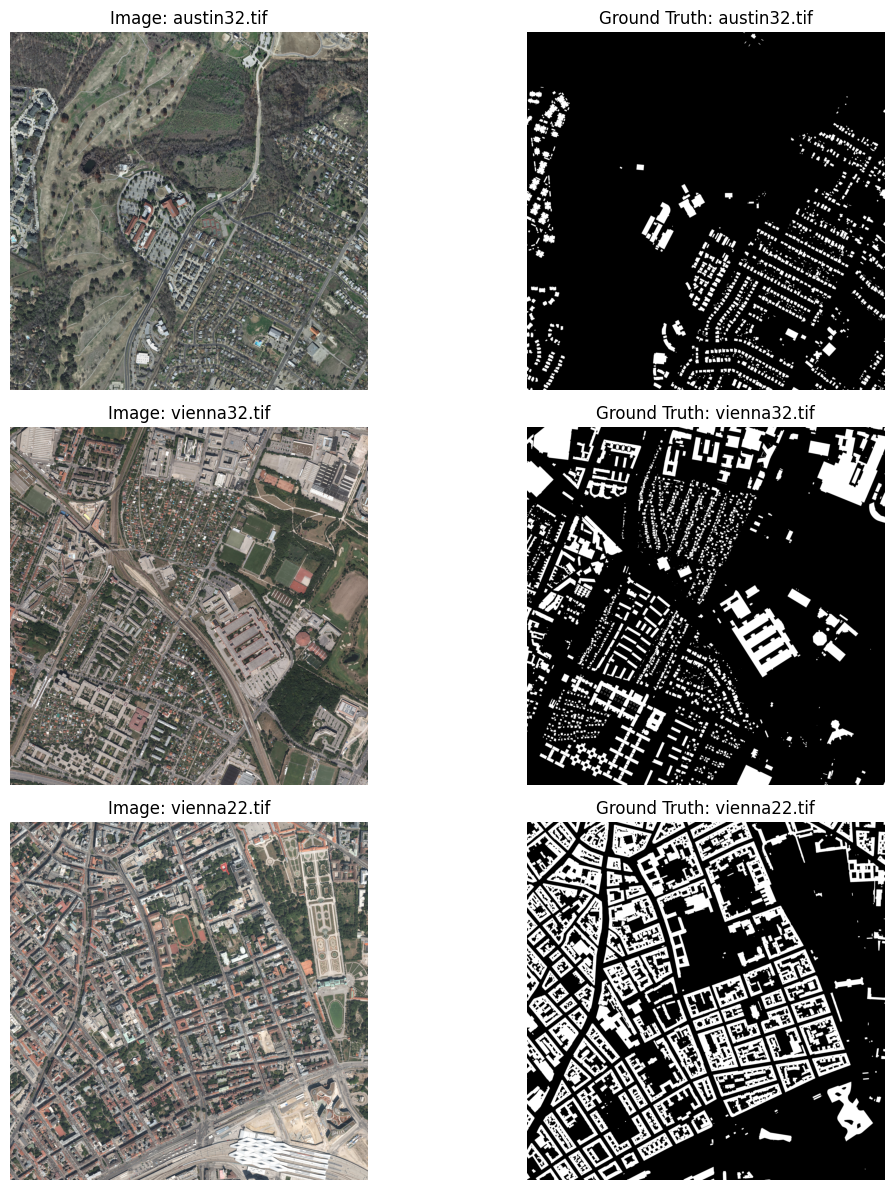

In [11]:
import matplotlib.pyplot as plt
import random

def plot_samples(img_files, gt_files, num_samples=3):
    plt.figure(figsize=(12, 4 * num_samples))
    
    # Pick random indices
    indices = random.sample(range(len(img_files)), num_samples)
    
    for i, idx in enumerate(indices):
        img_path = img_files[idx]
        # Construct matching gt path using filename
        filename = os.path.basename(img_path)
        gt_path = os.path.join(train_gt_path, filename)
        
        # --- FIX: Using PIL.Image.open() instead of tifffile ---
        try:
            img = np.array(Image.open(img_path))
            mask = np.array(Image.open(gt_path))
        except Exception as e:
            print(f"Error loading {filename}: {e}")
            continue
        
        # Plot Image
        plt.subplot(num_samples, 2, 2*i + 1)
        plt.imshow(img)
        plt.title(f"Image: {filename}")
        plt.axis("off")
        
        # Plot Mask
        plt.subplot(num_samples, 2, 2*i + 2)
        plt.imshow(mask, cmap="gray") # Gray cmap helps visualize binary masks
        plt.title(f"Ground Truth: {filename}")
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()

plot_samples(train_img_files, train_gt_files)

In [12]:
# Calculate pixel distribution on a subset to save time
subset_size = 5
indices = random.sample(range(len(train_gt_files)), subset_size)

building_pixels = 0
total_pixels = 0

print(f"Calculating class balance on {subset_size} random images...")

for idx in indices:
    # Load with PIL
    mask = np.array(Image.open(train_gt_files[idx]))
    
    # Assuming 255 (or > 0) is building
    building_pixels += np.sum(mask > 0)
    total_pixels += mask.size

background_pixels = total_pixels - building_pixels
building_ratio = (building_pixels / total_pixels) * 100

print(f"Total Pixels Scanned: {total_pixels}")
print(f"Building Pixels: {building_pixels}")
print(f"Building Ratio: {building_ratio:.2f}%")
print(f"Background Ratio: {100 - building_ratio:.2f}%")

Calculating class balance on 5 random images...
Total Pixels Scanned: 125000000
Building Pixels: 24239784
Building Ratio: 19.39%
Background Ratio: 80.61%
